# 🖼️ Image Captioning con CNN + LSTM
**Procesamiento del Lenguaje Natural para IA**

Arquitectura basada en *Show and Tell* (Vinyals et al., 2015):
- **Encoder**: ResNet-50 preentrenada en ImageNet (pesos congelados)
- **Embeddings**: Aprendidos desde cero durante el entrenamiento
- **Decoder**: LSTM que genera la descripción palabra a palabra
- **Dataset**: Flickr8k o Flickr30k (configurable en la celda siguiente)

> ⚠️ Antes de ejecutar: **Entorno de ejecución → Cambiar tipo → T4 GPU**

## 0. Instalaciones y librerías

In [ ]:
# ============================================================
# ✏️  CONFIGURACIÓN — solo cambia este valor
#     8  → Flickr8k  (8.000 imágenes, ~1h entrenamiento)
#     30 → Flickr30k (30.000 imágenes, ~3-4h entrenamiento)
# ============================================================

DATASET = 8   # <-- pon 8 o 30

# ── Configuración automática según el dataset elegido ──────
if DATASET == 8:
    DATASET_DIR    = 'flickr8k'
    IMG_DIR        = 'flickr8k/Images'
    CAPTIONS_FILE  = 'flickr8k/captions.txt'
    CAPTIONS_SEP   = 'comma'      # formato: image,caption
    TRAIN_SIZE     = 6000
    VAL_SIZE       = 1000
    KAGGLE_DATASET = 'adityajn105/flickr8k'
    KAGGLE_ZIP     = 'flickr8k.zip'
elif DATASET == 30:
    DATASET_DIR    = 'flickr30k'
    IMG_DIR        = 'flickr30k/flickr30k_images'
    CAPTIONS_FILE  = 'flickr30k/results.csv'
    CAPTIONS_SEP   = 'pipe'       # formato: image|idx|caption
    TRAIN_SIZE     = 28000
    VAL_SIZE       = 1000
    KAGGLE_DATASET = 'hsankesara/flickr-image-dataset'
    KAGGLE_ZIP     = 'flickr-image-dataset.zip'
else:
    raise ValueError('DATASET debe ser 8 o 30')

print(f'Dataset seleccionado: Flickr{DATASET}k')
print(f'  Imágenes train : {TRAIN_SIZE}')
print(f'  Directorio     : {DATASET_DIR}')


## 1. Descarga del dataset

La celda de configuración anterior determina qué dataset se descarga.
Necesitas tu `kaggle.json` (API key).
Puedes obtenerla en: **kaggle.com → tu perfil → Settings → API → Create New Token**

> Si ya tienes el dataset en Drive, salta esta sección y monta Drive directamente.

In [ ]:
# Configuramos la API key de Kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descargamos el dataset seleccionado
import os
if not os.path.exists(DATASET_DIR):
    print(f'Descargando Flickr{DATASET}k...')
    os.system(f'kaggle datasets download -d {KAGGLE_DATASET}')
    os.system(f'unzip -q {KAGGLE_ZIP} -d {DATASET_DIR}')
    print('Dataset descargado y descomprimido ✓')
else:
    print(f'Dataset ya disponible en {DATASET_DIR} ✓')

In [ ]:
# ============================================================
# PASO 1: Cargamos y limpiamos las captions del dataset
# Cada imagen tiene 5 descripciones asociadas.
# Flickr8k usa formato CSV (image,caption)
# Flickr30k usa formato pipe (image|idx|caption)
# ============================================================

def load_captions(captions_file, sep):
    captions = {}
    with open(captions_file, 'r') as f:
        next(f)  # saltamos cabecera
        for line in f:
            line = line.strip()
            if not line:
                continue
            if sep == 'comma':
                img_name, caption = line.split(',', 1)
            else:  # pipe
                parts = line.split('|')
                img_name = parts[0].strip()
                caption  = parts[2].strip() if len(parts) > 2 else ''
            img_name = img_name.strip()
            caption  = caption.strip().lower()
            if img_name not in captions:
                captions[img_name] = []
            captions[img_name].append(caption)
    return captions


def clean_caption(caption):
    caption = ''.join(c for c in caption if c.isalpha() or c == ' ')
    tokens = [w for w in caption.split() if len(w) > 1]
    return ' '.join(tokens)


raw_captions = load_captions(CAPTIONS_FILE, CAPTIONS_SEP)
clean_captions = {}
for img, caps in raw_captions.items():
    clean_captions[img] = [clean_caption(c) for c in caps]

ejemplo_img = list(clean_captions.keys())[0]
print(f'Imagen: {ejemplo_img}')
for i, cap in enumerate(clean_captions[ejemplo_img]):
    print(f'  Caption {i+1}: {cap}')
print(f'\nTotal de imágenes: {len(clean_captions)}')


In [ ]:
# ============================================================
# PASO 1: Cargamos y limpiamos las captions del dataset
# Cada imagen tiene 5 descripciones asociadas
# ============================================================

def load_captions(captions_file):
    """
    Lee el fichero de captions y devuelve un diccionario
    {nombre_imagen: [caption1, caption2, ...]}
    """
    captions = {}
    with open(captions_file, 'r') as f:
        next(f)  # saltamos la cabecera 'image,caption'
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Separamos solo por la primera coma para no romper captions con comas
            img_name, caption = line.split(',', 1)
            img_name = img_name.strip()
            caption = caption.strip().lower()
            if img_name not in captions:
                captions[img_name] = []
            captions[img_name].append(caption)
    return captions


def clean_caption(caption):
    """
    Limpieza básica: minúsculas, eliminar puntuación y números,
    quedarnos solo con palabras de más de 1 carácter.
    """
    # Eliminamos caracteres que no sean letras o espacios
    caption = ''.join(c for c in caption if c.isalpha() or c == ' ')
    # Normalizamos espacios y filtramos tokens cortos
    tokens = [w for w in caption.split() if len(w) > 1]
    return ' '.join(tokens)


# Cargamos y limpiamos
raw_captions = load_captions('flickr8k/captions.txt')
clean_captions = {}
for img, caps in raw_captions.items():
    clean_captions[img] = [clean_caption(c) for c in caps]

# Mostramos un ejemplo
ejemplo_img = list(clean_captions.keys())[0]
print(f'Imagen: {ejemplo_img}')
for i, cap in enumerate(clean_captions[ejemplo_img]):
    print(f'  Caption {i+1}: {cap}')

print(f'\nTotal de imágenes: {len(clean_captions)}')

Imagen: 1000268201_693b08cb0e.jpg
  Caption 1: child in pink dress is climbing up set of stairs in an entry way
  Caption 2: girl going into wooden building
  Caption 3: little girl climbing into wooden playhouse
  Caption 4: little girl climbing the stairs to her playhouse
  Caption 5: little girl in pink dress going into wooden cabin

Total de imágenes: 8091


In [ ]:
# ============================================================
# PASO 3: División train / val / test
# Los tamaños vienen de la celda de configuración.
# ============================================================

all_images = sorted(list(clean_captions.keys()))
random.seed(42)
random.shuffle(all_images)

train_imgs = all_images[:TRAIN_SIZE]
val_imgs   = all_images[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
test_imgs  = all_images[TRAIN_SIZE + VAL_SIZE:]

print(f'Train: {len(train_imgs)} imágenes')
print(f'Val:   {len(val_imgs)} imágenes')
print(f'Test:  {len(test_imgs)} imágenes')


Vocabulario construido: 2985 palabras (min_freq=5)

Original : child in pink dress is climbing up set of stairs in an entry way
Codificado: [1, 4, 5, 6, 7, 8, 9, 10]...
Decodificado: child in pink dress is climbing up set of stairs in an <UNK> way


In [ ]:
# ============================================================
# PASO 3: División train / val / test
# Usamos los splits estándar de Flickr8k:
# 6000 train, 1000 val, 1000 test
# ============================================================

all_images = sorted(list(clean_captions.keys()))
random.seed(42)  # fijamos la semilla para reproducibilidad
random.shuffle(all_images)

train_imgs = all_images[:6000]
val_imgs   = all_images[6000:7000]
test_imgs  = all_images[7000:]

print(f'Train: {len(train_imgs)} imágenes')
print(f'Val:   {len(val_imgs)} imágenes')
print(f'Test:  {len(test_imgs)} imágenes')

Train: 6000 imágenes
Val:   1000 imágenes
Test:  1091 imágenes


## 3. Dataset y DataLoader

In [ ]:
# ============================================================
# Definimos el Dataset de PyTorch.
# En cada __getitem__ devolvemos:
#   - imagen: tensor [3, 224, 224] normalizado para ResNet
#   - caption: tensor de índices del vocabulario
# Durante el entrenamiento usamos una sola caption aleatoria
# de las 5 disponibles por imagen (data augmentation ligero).
# ============================================================

# Transformaciones de imagen para ResNet:
# - Redimensionamos a 256 y hacemos crop central de 224
# - Normalizamos con media y std de ImageNet
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),       # augmentation: crop aleatorio en train
    transforms.RandomHorizontalFlip(), # augmentation: flip horizontal
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),        # en val/test, crop fijo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class Flickr8kDataset(Dataset):
    def __init__(self, image_names, captions_dict, vocab,
                 img_dir, transform=None, mode='train'):
        self.image_names   = image_names
        self.captions_dict = captions_dict
        self.vocab         = vocab
        self.img_dir       = img_dir
        self.transform     = transform
        self.mode          = mode  # 'train' o 'val'/'test'

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Cargamos la imagen en RGB (algunas imágenes en Flickr son RGBA o L)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # En train usamos una caption aleatoria de las 5 disponibles
        # En val/test usamos siempre la primera (evaluación consistente)
        caps = self.captions_dict[img_name]
        if self.mode == 'train':
            caption = random.choice(caps)
        else:
            caption = caps[0]

        caption_tensor = torch.tensor(self.vocab.encode(caption),
                                      dtype=torch.long)
        return image, caption_tensor


def collate_fn(batch):
    """
    Función de collate personalizada para el DataLoader.
    Las captions tienen longitudes distintas, así que las
    rellenamos con <PAD> (índice 0) hasta la longitud máxima del batch.
    """
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)

    # Longitud máxima de caption en este batch
    max_len = max(cap.size(0) for cap in captions)

    # Rellenamos con ceros (<PAD>) las captions más cortas
    padded = torch.zeros(len(captions), max_len, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :cap.size(0)] = cap

    return images, padded


# Creamos los datasets y dataloaders
IMG_DIR = 'flickr8k/Images'
BATCH_SIZE = 64

train_dataset = Flickr8kDataset(train_imgs, clean_captions, vocab,
                                IMG_DIR, train_transform, mode='train')
val_dataset   = Flickr8kDataset(val_imgs,  clean_captions, vocab,
                                IMG_DIR, val_transform,   mode='val')
test_dataset  = Flickr8kDataset(test_imgs, clean_captions, vocab,
                                IMG_DIR, val_transform,   mode='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f'Batches en train: {len(train_loader)}')
print(f'Batches en val:   {len(val_loader)}')

# Comprobamos que un batch tiene la forma correcta
imgs_batch, caps_batch = next(iter(train_loader))
print(f'\nForma de un batch de imágenes: {imgs_batch.shape}')  # [64, 3, 224, 224]
print(f'Forma de un batch de captions: {caps_batch.shape}')    # [64, max_len]

Batches en train: 94
Batches en val:   16

Forma de un batch de imágenes: torch.Size([64, 3, 224, 224])
Forma de un batch de captions: torch.Size([64, 20])


## 4. Embeddings aprendidos desde cero

En lugar de usar vectores GloVe preentrenados, los embeddings se aprenden
directamente a partir de las captions de Flickr8k durante el entrenamiento.
Esto elimina la dependencia de recursos externos y permite que las
representaciones se adapten al dominio específico del dataset.

La capa `nn.Embedding` se inicializa aleatoriamente y sus pesos se
actualizan por backpropagation junto con el resto del decoder.

In [ ]:
# ============================================================
# Definimos la dimensión de los embeddings.
# Al aprender desde cero, usamos 256d para dar más capacidad
# al modelo respecto a los 100d de GloVe.
# ============================================================

EMBED_DIM = 256  # dimensión de los embeddings aprendidos

print(f'Embeddings de dimensión {EMBED_DIM} se aprenderán desde cero')
print(f'Vocabulario: {len(vocab)} palabras')

Embeddings de dimensión 256 se aprenderán desde cero
Vocabulario: 2985 palabras


In [ ]:
# ============================================================
# No se necesita cargar ningún fichero externo.
# La matriz de embeddings se inicializa en el modelo directamente.
# ============================================================

print('Sin embeddings preentrenados: los pesos se aprenderán durante el entrenamiento ✓')

Sin embeddings preentrenados: los pesos se aprenderán durante el entrenamiento ✓


## 5. Modelo: Encoder (ResNet-50) + Decoder (LSTM)

In [ ]:
# ============================================================
# ENCODER: ResNet-50 preentrenada
# Eliminamos la capa de clasificación final y añadimos
# una proyección lineal para adaptar las features de 2048
# dimensiones al espacio de embeddings.
# Los pesos de ResNet se congelan para ahorrar tiempo y
# evitar overfitting con un dataset pequeño.
# ============================================================

class EncoderCNN(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.projection = nn.Linear(resnet.fc.in_features, embed_dim)
        self.bn = nn.BatchNorm1d(embed_dim)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)   # [batch, 2048, 1, 1]
        features = features.squeeze(-1).squeeze(-1)   # [batch, 2048]
        features = self.bn(self.projection(features)) # [batch, embed_dim]
        return features


# ============================================================
# DECODER: LSTM con embeddings aprendidos desde cero
# La capa nn.Embedding se inicializa aleatoriamente y sus
# pesos se actualizan durante el entrenamiento por backprop.
# ============================================================

class DecoderLSTM(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Proyección para adaptar el vector visual al tamaño del hidden state
        self.init_h = nn.Linear(embed_dim, hidden_dim)

        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            batch_first=True,
                            dropout=dropout if dropout > 0 else 0)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embedding(captions[:, :-1]))

        # Proyectamos features [batch, embed_dim] → [batch, hidden_dim]
        h0 = torch.tanh(self.init_h(features)).unsqueeze(0)  # [1, batch, hidden_dim]
        c0 = torch.zeros_like(h0)

        output, _ = self.lstm(embeddings, (h0, c0))
        logits = self.fc(self.dropout(output))
        return logits


# ============================================================
# Modelo completo: Encoder + Decoder
# ============================================================

class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderLSTM(embed_dim, hidden_dim, vocab_size)

    def forward(self, images, captions):
        features = self.encoder(images)
        logits   = self.decoder(features, captions)
        return logits


HIDDEN_DIM = 512

model = ImageCaptioningModel(
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    vocab_size=len(vocab)
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,} total')

Parámetros entrenables: 4,529,065 / 28,037,097 total


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


## 6. Entrenamiento

In [ ]:
# ============================================================
# Configuración del entrenamiento:
# - CrossEntropyLoss ignorando el padding (<PAD> = índice 0)
# - Adam como optimizador (solo sobre parámetros entrenables)
# - ReduceLROnPlateau: reduce el LR si la val_loss no mejora
# ============================================================

# Conectamos Google Drive para guardar checkpoints
from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/image_captioning_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Loss: ignoramos el token de padding en el cálculo
criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx['<PAD>'])

# Optimizador: solo actualizamos los parámetros entrenables
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=4e-4
)

# Scheduler: reduce el LR a la mitad si val_loss no mejora en 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Funciones de entrenamiento y validación por epoch
# ============================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta un epoch completo de entrenamiento."""
    model.train()
    total_loss = 0.0

    for images, captions in loader:
        images   = images.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(images, captions)
        # logits:   [batch, seq_len-1, vocab_size]
        # targets:  [batch, seq_len-1]  (quitamos el <SOS>)

        # Reorganizamos para CrossEntropyLoss
        logits  = logits.reshape(-1, logits.size(-1))  # [batch*(seq-1), vocab]
        targets = captions[:, 1:].reshape(-1)           # [batch*(seq-1)]

        loss = criterion(logits, targets)
        loss.backward()

        # Gradient clipping: evita exploding gradients en la LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def val_epoch(model, loader, criterion, device):
    """Evalúa el modelo en el conjunto de validación."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, captions in loader:
            images   = images.to(device)
            captions = captions.to(device)
            logits   = model(images, captions)
            logits   = logits.reshape(-1, logits.size(-1))
            targets  = captions[:, 1:].reshape(-1)
            total_loss += criterion(logits, targets).item()

    return total_loss / len(loader)

In [ ]:
# ============================================================
# Bucle principal de entrenamiento
# Guardamos el mejor modelo (menor val_loss) en Drive
# ============================================================

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss   = val_epoch(model, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f'  → LR reducido: {old_lr:.2e} → {new_lr:.2e}')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': val_loss,
            'vocab': vocab
        }
        torch.save(checkpoint,
                   f'{CHECKPOINT_DIR}/best_model.pt')
        print(f'  → Nuevo mejor modelo guardado (val_loss={val_loss:.4f})')

print('\nEntrenamiento completado ✓')

Epoch 01/20 | Train Loss: 4.9216 | Val Loss: 4.7160
  → Nuevo mejor modelo guardado (val_loss=4.7160)
Epoch 02/20 | Train Loss: 4.6485 | Val Loss: 4.4749
  → Nuevo mejor modelo guardado (val_loss=4.4749)
Epoch 03/20 | Train Loss: 4.4539 | Val Loss: 4.2975
  → Nuevo mejor modelo guardado (val_loss=4.2975)
Epoch 04/20 | Train Loss: 4.3104 | Val Loss: 4.1678
  → Nuevo mejor modelo guardado (val_loss=4.1678)
Epoch 05/20 | Train Loss: 4.1973 | Val Loss: 4.0639
  → Nuevo mejor modelo guardado (val_loss=4.0639)
Epoch 06/20 | Train Loss: 4.1084 | Val Loss: 3.9787
  → Nuevo mejor modelo guardado (val_loss=3.9787)
Epoch 07/20 | Train Loss: 4.0102 | Val Loss: 3.9011
  → Nuevo mejor modelo guardado (val_loss=3.9011)
Epoch 08/20 | Train Loss: 3.9413 | Val Loss: 3.8432
  → Nuevo mejor modelo guardado (val_loss=3.8432)
Epoch 09/20 | Train Loss: 3.8695 | Val Loss: 3.7826
  → Nuevo mejor modelo guardado (val_loss=3.7826)
Epoch 10/20 | Train Loss: 3.8181 | Val Loss: 3.7369
  → Nuevo mejor modelo guardad

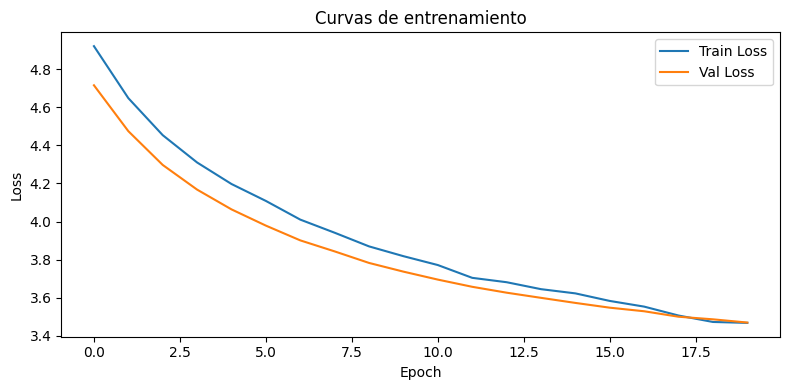

In [ ]:
# Visualizamos las curvas de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curvas de entrenamiento')
plt.legend()
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/training_curves.png', dpi=150)
plt.show()

## 7. Generación de captions (Greedy y Beam Search)

In [ ]:
# ============================================================
# Cargamos el mejor modelo guardado en Drive
# ============================================================

checkpoint = torch.load(f'{CHECKPOINT_DIR}/best_model.pt',
                        map_location=device,
                        weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Modelo cargado (epoch {checkpoint["epoch"]}, '
      f'val_loss={checkpoint["val_loss"]:.4f})')

Modelo cargado (epoch 20, val_loss=3.4693)


In [ ]:
# ============================================================
# GREEDY SEARCH
# En cada paso seleccionamos la palabra con mayor probabilidad.
# Simple y rápido, pero no siempre da la mejor secuencia global.
# ============================================================

@torch.no_grad()
def generate_greedy(model, image_tensor, vocab, max_len=30):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    features = model.encoder(image_tensor)  # [1, embed_dim]

    # Proyectamos igual que en el decoder
    h = torch.tanh(model.decoder.init_h(features)).unsqueeze(0)  # [1, 1, hidden_dim]
    c = torch.zeros_like(h)

    input_token = torch.tensor([[vocab.word2idx['<SOS>']]], device=device)
    generated = []
    for _ in range(max_len):
        emb = model.decoder.embedding(input_token)
        out, (h, c) = model.decoder.lstm(emb, (h, c))
        logits = model.decoder.fc(out.squeeze(1))
        next_token = logits.argmax(dim=-1)
        word = vocab.idx2word[next_token.item()]
        if word == '<EOS>':
            break
        generated.append(word)
        input_token = next_token.unsqueeze(0)
    return ' '.join(generated)


# ============================================================
# BEAM SEARCH
# Mantiene las k mejores hipótesis en cada paso.
# Produce resultados más coherentes que greedy.
# ============================================================

@torch.no_grad()
def generate_beam(model, image_tensor, vocab, beam_size=5, max_len=30):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    features = model.encoder(image_tensor)  # [1, embed_dim]

    # Proyectamos igual que en el decoder
    h0 = torch.tanh(model.decoder.init_h(features)).unsqueeze(0)  # [1, 1, hidden_dim]
    c0 = torch.zeros_like(h0)

    sos = vocab.word2idx['<SOS>']
    eos = vocab.word2idx['<EOS>']
    beams = [(0.0, [sos], h0, c0)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for log_prob, tokens, h, c in beams:
            last_token = torch.tensor([[tokens[-1]]], device=device)
            emb = model.decoder.embedding(last_token)
            out, (h_new, c_new) = model.decoder.lstm(emb, (h, c))
            logits = model.decoder.fc(out.squeeze(1))
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
            top_log_probs, top_tokens = log_probs.topk(beam_size)
            for lp, tok in zip(top_log_probs.tolist(), top_tokens.tolist()):
                new_seq = tokens + [tok]
                new_log_prob = log_prob + lp
                if tok == eos:
                    completed.append((new_log_prob, new_seq))
                else:
                    new_beams.append((new_log_prob, new_seq, h_new, c_new))
        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]
        if not beams:
            break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    best_log_prob, best_tokens = max(completed, key=lambda x: x[0] / max(len(x[1]), 1))
    return vocab.decode(best_tokens)

## 8. Evaluación con BLEU

In [ ]:
# ============================================================
# BLEU (Bilingual Evaluation Understudy)
# Compara n-gramas entre la descripción generada y las 5
# referencias humanas. Es la métrica estándar en los papers.
# BLEU-1: unigramas  | BLEU-4: 1-2-3-4 gramas combinados
# ============================================================

def evaluate_bleu(model, image_names, captions_dict, vocab,
                  img_dir, transform, device, beam_size=5, n_samples=500):
    """
    Calcula BLEU-1 y BLEU-4 sobre un subconjunto de imágenes.
    Usamos n_samples imágenes para que sea manejable en tiempo.
    """
    model.eval()
    smoothing = SmoothingFunction().method1  # evita BLEU=0 por n-gramas no encontrados

    references_all = []  # lista de listas de referencias tokenizadas
    hypotheses_all = []  # lista de hipótesis tokenizadas

    sample_names = random.sample(image_names, min(n_samples, len(image_names)))

    for img_name in sample_names:
        # Cargamos y transformamos la imagen
        img_path = os.path.join(img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image)

        # Generamos la descripción
        hypothesis = generate_beam(model, image_tensor, vocab,
                                   beam_size=beam_size)

        # Las 5 referencias humanas
        refs = [clean_caption(cap).split()
                for cap in captions_dict[img_name]]

        references_all.append(refs)
        hypotheses_all.append(hypothesis.split())

    # BLEU-1: solo unigramas
    bleu1 = corpus_bleu(references_all, hypotheses_all,
                        weights=(1, 0, 0, 0))
    # BLEU-4: media geométrica de 1-2-3-4 gramas
    bleu4 = corpus_bleu(references_all, hypotheses_all,
                        weights=(0.25, 0.25, 0.25, 0.25))
    return bleu1, bleu4


print('Calculando BLEU en test (puede tardar ~2-3 min)...')
bleu1, bleu4 = evaluate_bleu(
    model, test_imgs, clean_captions, vocab,
    IMG_DIR, val_transform, device, beam_size=5
)
print(f'\nResultados en test:')
print(f'  BLEU-1: {bleu1:.4f} ({bleu1*100:.2f})')
print(f'  BLEU-4: {bleu4:.4f} ({bleu4*100:.2f})')

Calculando BLEU en test (puede tardar ~2-3 min)...

Resultados en test:
  BLEU-1: 0.5014 (50.14)
  BLEU-4: 0.1259 (12.59)


## 9. Ejemplos cualitativos

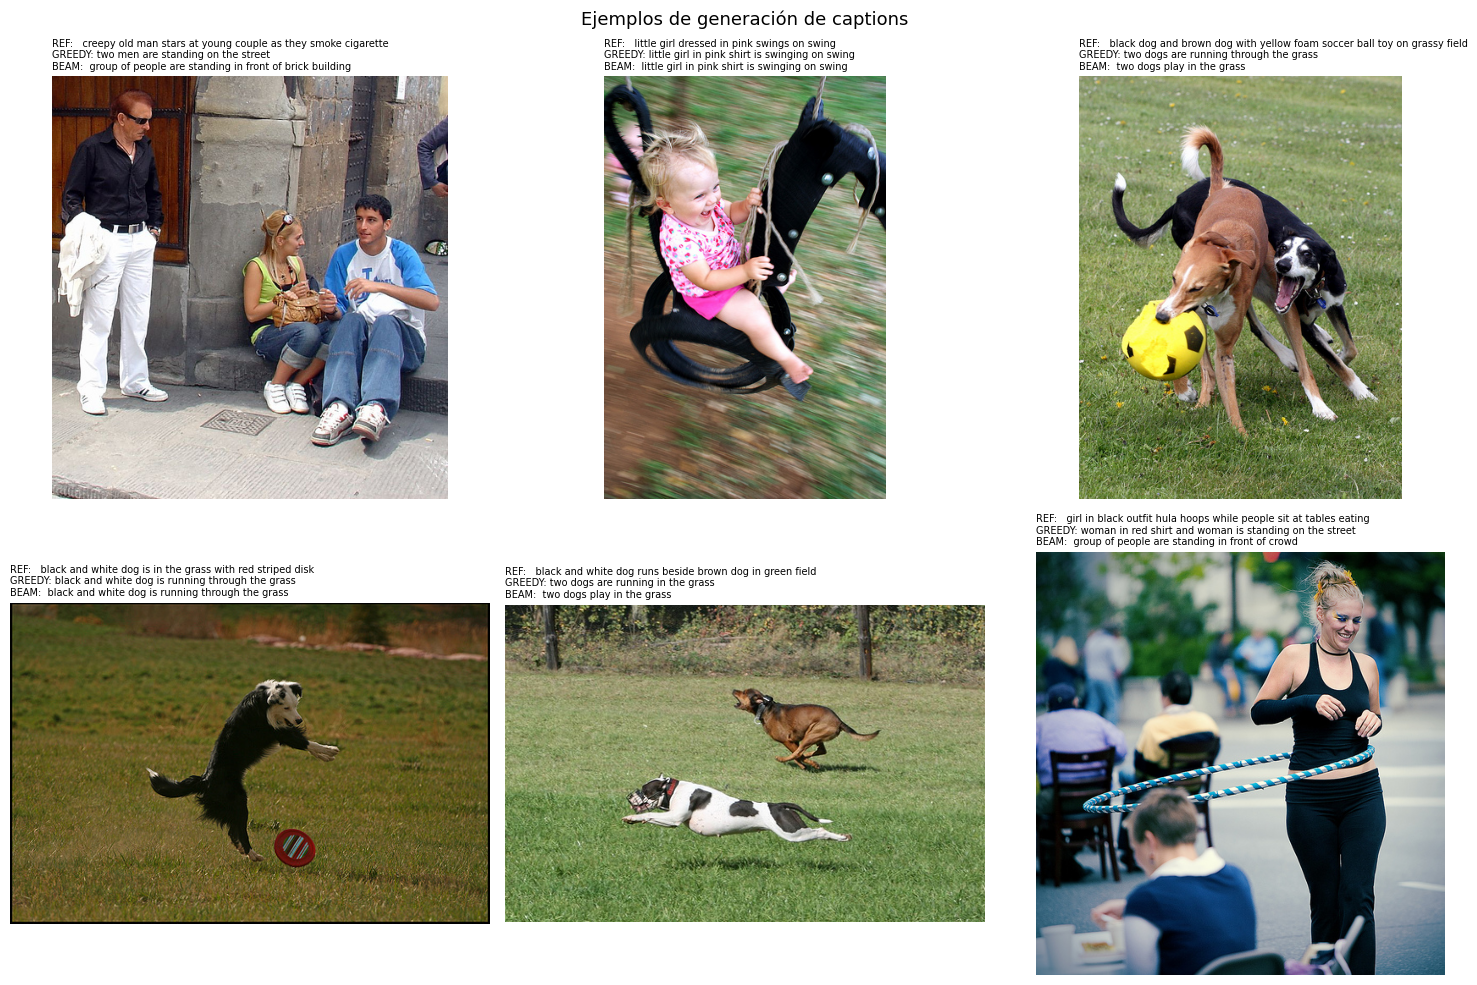

In [ ]:
# ============================================================
# Visualizamos algunos ejemplos del conjunto de test:
# imagen + captions de referencia + generación del modelo
# ============================================================

def show_examples(model, image_names, captions_dict, vocab,
                  img_dir, transform, device, n=6):
    model.eval()
    samples = random.sample(image_names, n)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for ax, img_name in zip(axes, samples):
        # Imagen original (sin normalizar, para visualización)
        img_path = os.path.join(img_dir, img_name)
        image_pil = Image.open(img_path).convert('RGB')
        image_tensor = transform(image_pil)

        greedy_cap = generate_greedy(model, image_tensor, vocab)
        beam_cap   = generate_beam(model, image_tensor, vocab, beam_size=5)

        # Una referencia humana de ejemplo
        ref = clean_captions[img_name][0]

        ax.imshow(image_pil)
        ax.axis('off')
        title = (f'REF:   {ref}\n'
                 f'GREEDY: {greedy_cap}\n'
                 f'BEAM:  {beam_cap}')
        ax.set_title(title, fontsize=7, loc='left', wrap=True)

    plt.suptitle('Ejemplos de generación de captions', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/ejemplos.png', dpi=150, bbox_inches='tight')
    plt.show()


show_examples(model, test_imgs, clean_captions, vocab,
              IMG_DIR, val_transform, device, n=6)

Sube una imagen para probar el modelo:


Saving prueba 7.avif to prueba 7 (1).avif


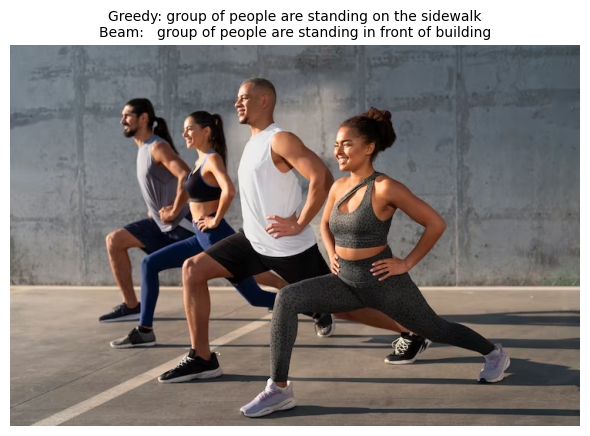

Greedy: group of people are standing on the sidewalk
Beam:   group of people are standing in front of building


In [29]:
# ============================================================
# EXTRA: prueba con una imagen propia
# Sube cualquier imagen y el modelo generará su descripción
# ============================================================

from google.colab import files

print('Sube una imagen para probar el modelo:')
uploaded = files.upload()

for filename in uploaded.keys():
    image_pil = Image.open(filename).convert('RGB')
    image_tensor = val_transform(image_pil)

    greedy_cap = generate_greedy(model, image_tensor, vocab)
    beam_cap   = generate_beam(model, image_tensor, vocab, beam_size=5)

    plt.figure(figsize=(6, 5))
    plt.imshow(image_pil)
    plt.axis('off')
    plt.title(f'Greedy: {greedy_cap}\nBeam:   {beam_cap}', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f'Greedy: {greedy_cap}')
    print(f'Beam:   {beam_cap}')